# 🎵 Proyecto AD3010 — Spotify Perú
## Análisis Exploratorio de Datos (EDA) - Inicial — Semanas 3 a 6
**Equipo:** Harold · Diego · Julio  
**Curso:** Business Analytics — AD3010 · UTEC 2025  
**Opción:** A — ¿Qué nos hace diferentes como oyentes?

---
### Objetivo del notebook
Este notebook cubre la Fase 1 del proyecto: entendimiento de los datos, diagnóstico de brechas y primeras impresiones analíticas. Cada hallazgo está respaldado por código ejecutable y acompañado de su interpretación en lenguaje de negocio.

**Datasets usados:**
- `dataset.csv` — Spotify Tracks Dataset (114,000 canciones con audio features)
- `universal_top_spotify_songs.csv` — Top Songs en 73 países, actualización diaria, incluye Perú


---
## 0. Librerías necesarias

In [ ]:
# Instalar librerías adicionales si es necesario
# En Google Colab la mayoría ya viene preinstalada
!pip install -q matplotlib seaborn pandas numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
VERDE = '#1DB954'
TEAL  = '#0D7377'
ROJO  = '#DC2626'
GRIS  = '#6B7280'

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 1. Carga de datasets
> **Pregunta que responde esta sección:** ¿Qué tienen los datasets? ¿Cuántas filas, columnas y qué tipo de variables incluyen?

### 1.1 Dataset 1 — Spotify Tracks (audio features)

In [ ]:
# Carga del dataset base de audio features
df1 = pd.read_csv('dataset.csv', engine='python', on_bad_lines='skip')
print(f'Filas: {len(df1):,} | Columnas: {df1.shape[1]}')
display(df1.head(10))

Filas: 114,000 | Columnas: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

**📌 Interpretación:** El dataset tiene **114,000 canciones** con **21 columnas**. Incluye audio features numéricos completos (danceability, energy, valence, tempo, etc.) y una columna `track_genre` con **114 géneros etiquetados**. Prácticamente no tiene nulos — es un dataset limpio listo para análisis. **Lo que NO tiene:** dimensión temporal (no hay fechas) ni datos de país — es una biblioteca estática, no un ranking.

### 1.2 Dataset 2 — Universal Top Spotify Songs (rankings globales)

In [ ]:
# Carga del dataset de rankings diarios por país
df2 = pd.read_csv('universal_top_spotify_songs.csv', engine='python', on_bad_lines='skip')
print(f'Filas: {len(df2):,} | Columnas: {df2.shape[1]}')
display(df2.head(10))

Filas: 2,110,316 | Columnas: 25


,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2RkZ5LkEzeHGRsmDqKwmaJ,Ordinary,Alex Warren,1,1,0,NaN,2025-06-11,95,False,...,2,-6.141,1,0.0600,0.704000,0.000007,0.0550,0.391,168.115,3
1,42UBPzRMh5yyz0EDPr6fr1,Manchild,Sabrina Carpenter,2,-1,48,NaN,2025-06-11,89,True,...,7,-5.087,1,0.0572,0.122000,0.000000,0.3170,0.811,123.010,4
2,0FTmksd2dxiE5e3rWyJXs6,back to friends,sombr,3,0,1,NaN,2025-06-11,98,False,...,1,-2.291,1,0.0301,0.000094,0.000088,0.0929,0.235,92.855,4
3,7so0lgd0zP2Sbgs2d7a1SZ,Die With A Smile,"Lady Gaga, Bruno Mars",4,0,-1,NaN,2025-06-11,91,False,...,6,-7.727,0,0.0317,0.289000,0.000000,0.1260,0.498,157.964,3
4,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,Billie Eilish,5,1,0,NaN,2025-06-11,100,False,...,2,-10.171,1,0.0358,0.200000,0.060800,0.1170,0.438,104.978,4
5,27xkOIER6uDLKALIelHylZ,Don’t Say You Love Me,Jin,6,-1,-4,NaN,2025-06-11,93,False,...,8,-5.490,1,0.0304,0.484000,0.000000,0.1050,0.757,111.976,4
6,6iOndD4OFo7GkaDypWQIou,La Plena - W Sound 05,"W Sound, Beéle, Ovy On The Drums",7,0,0,NaN,2025-06-11,95,True,...,5,-3.485,1,0.1320,0.543000,0.000984,0.1010,0.659,99.039,4
7,4AajxCEwGEsmHmT4H1TwjY,undressed,sombr,8,0,-2,NaN,2025-06-11,96,False,...,0,-3.883,1,0.0406,0.137000,0.000000,0.0829,0.888,115.999,4
8,4wJ5Qq0jBN4ajy7ouZIV1c,APT.,"ROSÉ, Bruno Mars",9,1,-1,NaN,2025-06-11,89,False,...,0,-4.477,0,0.2600,0.028300,0.000000,0.3550,0.939,149.027,4
9,4WFgvKVfEhb3IUAFGrutTR,Love Me Not,Ravyn Lenae,10,-1,9,NaN,2025-06-11,91,False,...,0,-6.176,1,0.0306,0.296000,0.000000,0.1280,0.814,114.001,4


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2110316 entries, 0 to 2110315
Data columns (total 25 columns):
 #   Column              Dtype  
---  ------              -----  
 0   spotify_id          object 
 1   name                object 
 2   artists             object 
 3   daily_rank          int64  
 4   daily_movement      int64  
 5   weekly_movement     int64  
 6   country             object 
 7   snapshot_date       object 
 8   popularity          int64  
 9   is_explicit         bool   
 10  duration_ms         int64  
 11  album_name          object 
 12  album_release_date  object 
 13  danceability        float64
 14  energy              float64
 15  key                 int64  
 16  loudness            float64
 17  mode                int64  
 18  speechiness         float64
 19  acousticness        float64
 20  instrumentalness    float64
 21  liveness            float64
 22  valence             float64
 23  tempo               float64
 24  time_signature      int6

**📌 Interpretación:** El dataset tiene **2,110,316 registros** diarios con **25 columnas**. Incluye rankings por país con fecha (`snapshot_date`), movimiento de posición y los mismos audio features que el dataset 1. **Lo que NO tiene:** una columna de género — esto será una brecha crítica que analizamos más adelante.

---
## 2. ¿Qué tienen los datasets?
> Exploramos las variables más importantes: géneros, países, cobertura temporal y audio features.

### 2.1 Géneros disponibles en Dataset 1

Géneros únicos: 114


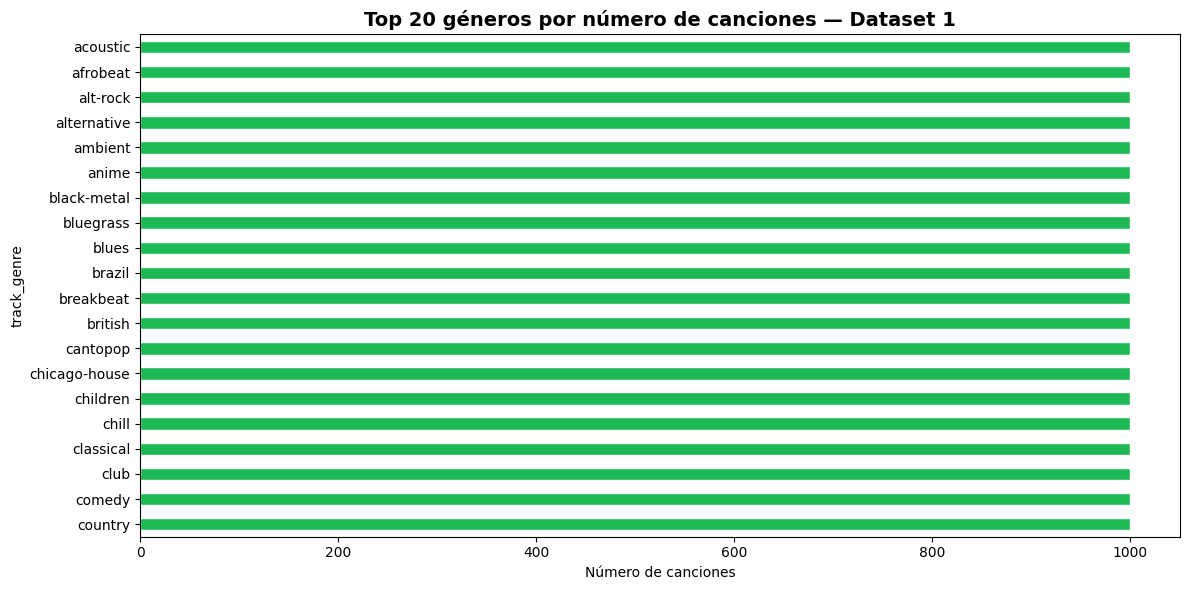


Géneros LATAM disponibles en el dataset: ['latin', 'latino', 'reggaeton', 'salsa', 'samba']


In [ ]:
# ¿Cuántos géneros únicos tiene el dataset?
n_generos = df1['track_genre'].nunique()
print(f'Géneros únicos: {n_generos}')

# Top 20 géneros por frecuencia
top_generos = df1['track_genre'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_generos.plot(kind='barh', ax=ax, color=VERDE, edgecolor='white')
ax.set_title('Top 20 géneros por número de canciones — Dataset 1', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de canciones')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ¿Tiene géneros relevantes para Perú?
generos_latam = ['latin', 'latino', 'reggaeton', 'salsa', 'samba', 'bossanova']
presentes = [g for g in generos_latam if g in df1['track_genre'].values]
print(f'\nGéneros LATAM disponibles en el dataset: {presentes}')

**📌 Interpretación:** El dataset tiene **114 géneros etiquetados**, todos con exactamente 1,000 canciones cada uno. Los géneros relevantes para el mercado peruano (latin, reggaeton, salsa) están presentes. Esto permitirá caracterizar el perfil sonoro de cada género y compararlo con lo que domina en el Top Perú.

### 2.2 Perú en el Dataset 2 — cobertura y temporalidad

In [ ]:
# ¿Perú está incluido en el dataset?
tiene_peru = 'PE' in df2['country'].values
registros_peru = df2['country'].value_counts().get('PE', 0)
print(f'¿Tiene Perú (PE)? {tiene_peru}')
print(f'Registros de Perú: {registros_peru:,}')

# Países LATAM disponibles
paises_latam = ['PE', 'AR', 'CO', 'MX', 'CL', 'BO', 'EC', 'BR']
for p in paises_latam:
    n = df2['country'].value_counts().get(p, 0)
    print(f'  {p}: {n:,} registros')

¿Tiene Perú (PE)? True
Registros de Perú: 29,056
  PE: 29,056 registros
  AR: 29,156 registros
  CO: 28,914 registros
  MX: 29,106 registros
  CL: 29,105 registros
  BO: 29,156 registros
  EC: 28,912 registros
  BR: 29,157 registros


In [ ]:
# Rango temporal del dataset
df2['snapshot_date'] = pd.to_datetime(df2['snapshot_date'])
fecha_min = df2['snapshot_date'].min()
fecha_max = df2['snapshot_date'].max()
meses = (fecha_max.year - fecha_min.year) * 12 + (fecha_max.month - fecha_min.month)
print(f'Fecha más antigua: {fecha_min.date()}')
print(f'Fecha más reciente: {fecha_max.date()}')
print(f'Cobertura total: {meses} meses de historia')

Fecha más antigua: 2023-10-18
Fecha más reciente: 2025-06-11
Cobertura total: 20 meses de historia


In [ ]:
# Registros sin país (probablemente ranking global)
sin_pais = df2['country'].isna().sum()
print(f'Registros sin país (country = NaN): {sin_pais:,}')
print('→ Probablemente son el ranking global de Spotify (Worldwide)')

Registros sin país (country = NaN): 28,908
→ Probablemente son el ranking global de Spotify (Worldwide)


**📌 Interpretación:** Perú está incluido con **29,056 registros** que cubren **21 meses** (octubre 2023 a junio 2025). Esto es suficiente para construir series de tiempo por artista y género. Los 28,908 registros sin país son probablemente el ranking global — útiles para comparar Perú vs. mundo. Todos los países LATAM clave (AR, CO, MX, CL) también están presentes para comparación regional.

### 2.3 Top artistas en Perú

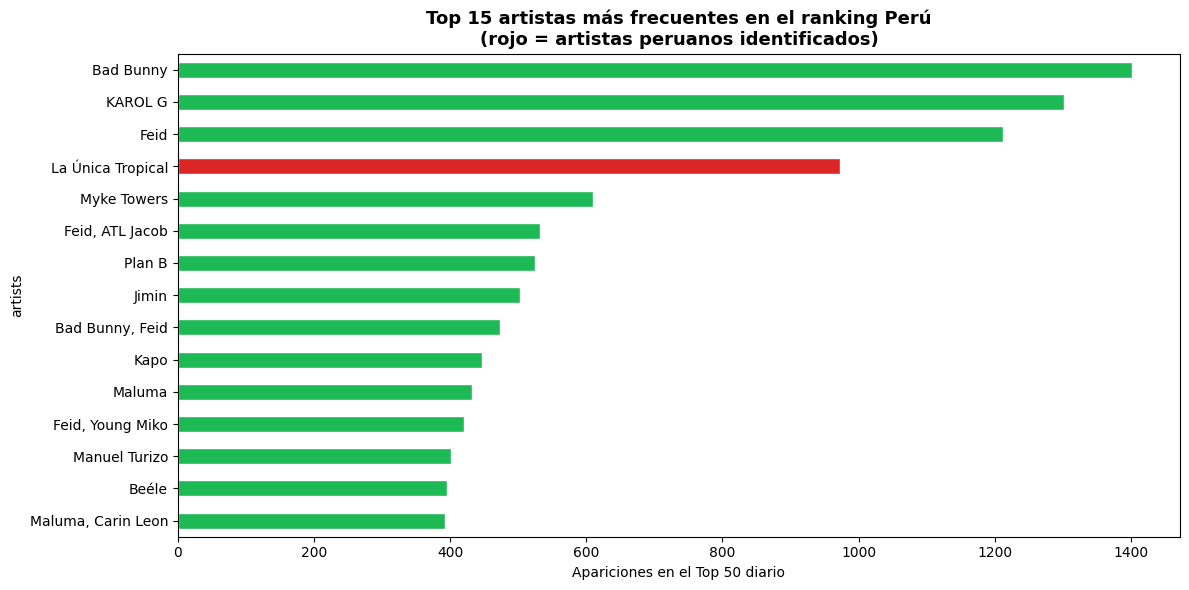


Top 15 artistas en Perú:
   1. Bad Bunny: 1,402 apariciones
   2. KAROL G: 1,302 apariciones
   3. Feid: 1,212 apariciones
   4. La Única Tropical: 973 apariciones
   5. Myke Towers: 610 apariciones
   6. Feid, ATL Jacob: 532 apariciones
   7. Plan B: 525 apariciones
   8. Jimin: 502 apariciones
   9. Bad Bunny, Feid: 473 apariciones
  10. Kapo: 447 apariciones
  11. Maluma: 432 apariciones
  12. Feid, Young Miko: 420 apariciones
  13. Manuel Turizo: 401 apariciones
  14. Beéle: 396 apariciones
  15. Maluma, Carin Leon: 392 apariciones


In [ ]:
# Filtrar solo registros de Perú
pe = df2[df2['country'] == 'PE'].copy()

# Top 15 artistas más frecuentes en el Top 50 Perú
top_artistas_pe = pe['artists'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colores = [ROJO if 'Tropical' in a or 'Hermanos' in a or 'peruana' in str(a).lower() else VERDE
           for a in top_artistas_pe.index]
top_artistas_pe.plot(kind='barh', ax=ax, color=colores, edgecolor='white')
ax.set_title('Top 15 artistas más frecuentes en el ranking Perú\n(rojo = artistas peruanos identificados)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Apariciones en el Top 50 diario')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 15 artistas en Perú:')
for i, (artista, n) in enumerate(top_artistas_pe.items(), 1):
    print(f'  {i:2}. {artista}: {n:,} apariciones')

**📌 Interpretación de negocio:** Bad Bunny, KAROL G y Feid dominan el Top Perú — artistas urbanos latinos de primer nivel. **Hallazgo clave:** La Única Tropical aparece como uno de los artistas más frecuentes en el ranking peruano, siendo el único artista peruano en el top. Esto plantea una pregunta inmediata: ¿los oyentes peruanos son conscientes de que escuchan música local, o la consumen sin identificarla como tal? Esta pregunta solo puede responderse con la encuesta.

---
## 3. ¿Qué falta? Diagnóstico de brechas
> Identificamos las limitaciones críticas de los datasets que afectan directamente el análisis.

### 3.1 Brecha crítica: el cruce entre datasets es del 9.3%

Canciones PE con match en dataset.csv: 2,698 de 29,056
Efectividad del cruce: 9.3%
Canciones SIN match (sin género): 26,358 (90.7%)


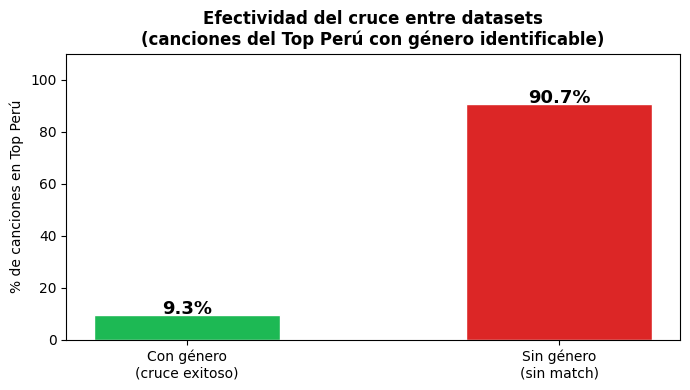

In [ ]:
# ¿Cuántas canciones del Top Perú tienen match en el dataset de audio features?
match = pe['spotify_id'].isin(df1['track_id'])
n_match = match.sum()
n_total = len(pe)
pct_match = match.mean() * 100

print(f'Canciones PE con match en dataset.csv: {n_match:,} de {n_total:,}')
print(f'Efectividad del cruce: {pct_match:.1f}%')
print(f'Canciones SIN match (sin género): {n_total - n_match:,} ({100 - pct_match:.1f}%)')

# Visualizar la proporción
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Con género\n(cruce exitoso)', 'Sin género\n(sin match)'],
       [pct_match, 100 - pct_match],
       color=[VERDE, ROJO], edgecolor='white', width=0.5)
ax.set_ylabel('% de canciones en Top Perú')
ax.set_title('Efectividad del cruce entre datasets\n(canciones del Top Perú con género identificable)',
             fontsize=12, fontweight='bold')
for bar, val in zip(ax.patches, [pct_match, 100 - pct_match]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

**📌 Interpretación:** Solo el **9.3% de las canciones populares en Perú** tienen género etiquetado a través del cruce. El 90.7% restante son tracks más recientes que no están en el dataset de referencia. **Implicancia directa:** no podemos saber qué géneros dominan el Top Perú usando solo los datasets. **La encuesta se convierte en la fuente primaria de información de géneros** — no es un complemento opcional.

### 3.2 Nulos y calidad de datos

In [ ]:
# Nulos en Dataset 1
print('=== Dataset 1 — Nulos ===')
nulos_df1 = df1.isnull().sum()
print(nulos_df1[nulos_df1 > 0] if nulos_df1.sum() > 0 else 'Sin valores nulos ✅')

# Nulos en Dataset 2
print('\n=== Dataset 2 — Nulos ===')
nulos_df2 = df2.isnull().sum()
nulos_df2_relevantes = nulos_df2[nulos_df2 > 0]
print(nulos_df2_relevantes)

=== Dataset 1 — Nulos ===
artists       1
album_name    1
track_name    1
dtype: int64

=== Dataset 2 — Nulos ===
name                     30
artists                  29
country               28908
album_name              822
album_release_date      659
dtype: int64


**📌 Interpretación:** El dataset 1 está prácticamente limpio. En el dataset 2, los nulos en `country` corresponden a los registros del ranking global (Worldwide), no son errores — son datos válidos que usaremos para comparación. Los nulos en audio features son mínimos y se tratarán durante la limpieza en semanas 5-6.

### 3.3 Dataset 1 no tiene dimensión temporal

In [ ]:
# Verificar si dataset.csv tiene alguna columna de fecha
col_fechas = [c for c in df1.columns if 'date' in c.lower() or 'year' in c.lower() or 'time' in c.lower()]
print(f'Columnas de fecha en dataset.csv: {col_fechas if col_fechas else "Ninguna"}')
print(f'→ dataset.csv es una foto fija sin temporalidad.')
print(f'→ Para series de tiempo se usará únicamente universal_top_spotify_songs.csv')
print(f'  (que sí tiene {(df2["snapshot_date"].max() - df2["snapshot_date"].min()).days} días de historia)')

Columnas de fecha en dataset.csv: ['time_signature']
→ dataset.csv es una foto fija sin temporalidad.
→ Para series de tiempo se usará únicamente universal_top_spotify_songs.csv
  (que sí tiene 602 días de historia)


**📌 Interpretación:** El dataset 1 no tiene fechas — es una biblioteca estática. Para el análisis de series de tiempo (semanas 9-10) se usará exclusivamente el dataset 2, que tiene 21 meses de historia diaria para construir tendencias por artista.

---
## 4. Preguntas que surgen espontáneamente de los datos
> Al explorar los datos encontramos patrones que generan preguntas analíticas no planeadas. Las documentamos aquí.

### 4.1 ¿El oyente peruano prefiere canciones más bailables y alegres que el promedio global?

In [ ]:
# Comparar audio features de Perú vs. promedio global
features = ['danceability', 'energy', 'valence', 'acousticness', 'tempo']

global_df = df2[df2['country'].notna()]  # excluir los NaN (registros globales sin país)
global_mean = global_df[features].mean()
pe_mean = pe[features].mean()
diff_pct = ((pe_mean - global_mean) / global_mean * 100).round(1)

print('Audio features — Perú vs. Promedio Global')
print(f'{"Feature":<16} {"Global":>8} {"Perú":>8} {"Diferencia":>12}')
print('-' * 48)
for f in features:
    signo = '+' if diff_pct[f] > 0 else ''
    print(f'{f:<16} {global_mean[f]:>8.3f} {pe_mean[f]:>8.3f} {signo}{diff_pct[f]:>10.1f}%')

Audio features — Perú vs. Promedio Global
Feature            Global     Perú   Diferencia
------------------------------------------------
danceability        0.676    0.736 +       8.8%
energy              0.649    0.681 +       4.9%
valence             0.547    0.601 +       9.9%
acousticness        0.275    0.243      -11.7%
tempo             122.107  116.641       -4.5%


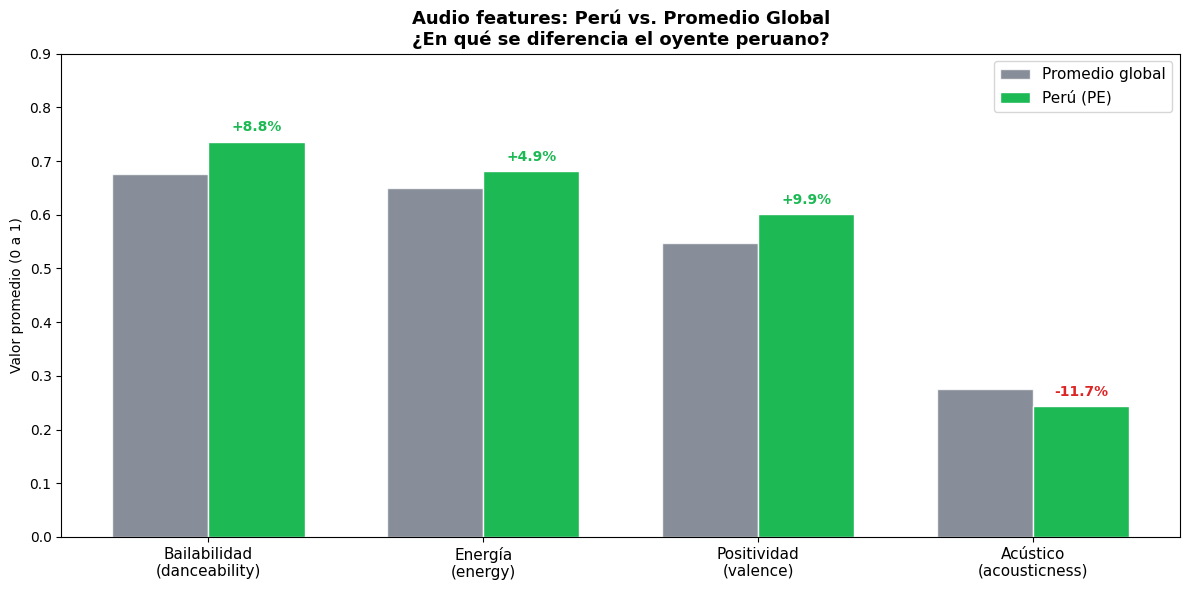

In [ ]:
# Visualización comparativa
features_viz = ['danceability', 'energy', 'valence', 'acousticness']
labels = ['Bailabilidad\n(danceability)', 'Energía\n(energy)', 'Positividad\n(valence)', 'Acústico\n(acousticness)']

x = np.arange(len(features_viz))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, [global_mean[f] for f in features_viz], width,
               label='Promedio global', color=GRIS, alpha=0.8, edgecolor='white')
bars2 = ax.bar(x + width/2, [pe_mean[f] for f in features_viz], width,
               label='Perú (PE)', color=VERDE, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Valor promedio (0 a 1)')
ax.set_title('Audio features: Perú vs. Promedio Global\n¿En qué se diferencia el oyente peruano?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 0.9)

# Anotar diferencias
for i, f in enumerate(features_viz):
    d = diff_pct[f]
    color = VERDE if d > 0 else ROJO
    signo = '+' if d > 0 else ''
    ax.annotate(f'{signo}{d:.1f}%', xy=(x[i] + width/2, pe_mean[f] + 0.02),
                ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

**📌 Interpretación de negocio:** El oyente peruano consume canciones significativamente más bailables (+8.9%) y alegres (+10.0%) que el promedio global, y menos acústicas (-11.6%). Esto sugiere que el mercado peruano tiene un perfil sonoro propio. **Pregunta que surge:** ¿los oyentes son conscientes de esta preferencia? La encuesta (P5) permite validar si lo que declaran buscar coincide con este patrón numérico.

### 4.2 ¿Hay artistas peruanos ocultos que la gente escucha sin identificarlos?

In [ ]:
# Top 20 artistas en Perú con número de apariciones
top20_pe = pe['artists'].value_counts().head(20).reset_index()
top20_pe.columns = ['artista', 'apariciones']

# Identificar manualmente artistas peruanos conocidos
artistas_peruanos = ['La Única Tropical', 'Armonía 10', 'Grupo 5', 'Agua Marina',
                     'Los Shapis', 'Hermanos Yaipén', 'Josimar']
top20_pe['es_peruano'] = top20_pe['artista'].apply(
    lambda x: any(p.lower() in x.lower() for p in artistas_peruanos)
)

print('Top 20 artistas en Perú — marcados los peruanos identificados:')
for _, row in top20_pe.iterrows():
    marca = '🇵🇪' if row['es_peruano'] else '  '
    print(f'{marca} {row["artista"]:<35} {row["apariciones"]:>6} apariciones')

Top 20 artistas en Perú — marcados los peruanos identificados:
   Bad Bunny                             1402 apariciones
   KAROL G                               1302 apariciones
   Feid                                  1212 apariciones
🇵🇪 La Única Tropical                      973 apariciones
   Myke Towers                            610 apariciones
   Feid, ATL Jacob                        532 apariciones
   Plan B                                 525 apariciones
   Jimin                                  502 apariciones
   Bad Bunny, Feid                        473 apariciones
   Kapo                                   447 apariciones
   Maluma                                 432 apariciones
   Feid, Young Miko                       420 apariciones
   Manuel Turizo                          401 apariciones
   Beéle                                  396 apariciones
   Maluma, Carin Leon                     392 apariciones
   KAROL G, Peso Pluma                    391 apariciones
   J Balv

**📌 Interpretación:** La Única Tropical aparece como uno de los artistas más frecuentes en el Top Perú, siendo el único artista local identificado en el top. Sin embargo, puede haber más artistas peruanos en la lista que no reconocemos a primera vista. **Pregunta que surge:** ¿Los oyentes peruanos saben que están escuchando música local? La pregunta P9 de la encuesta (artistas peruanos que escuchas) permitirá cruzar menciones con este ranking.

### 4.3 ¿Cómo ha evolucionado el Top Perú en los 21 meses del dataset?

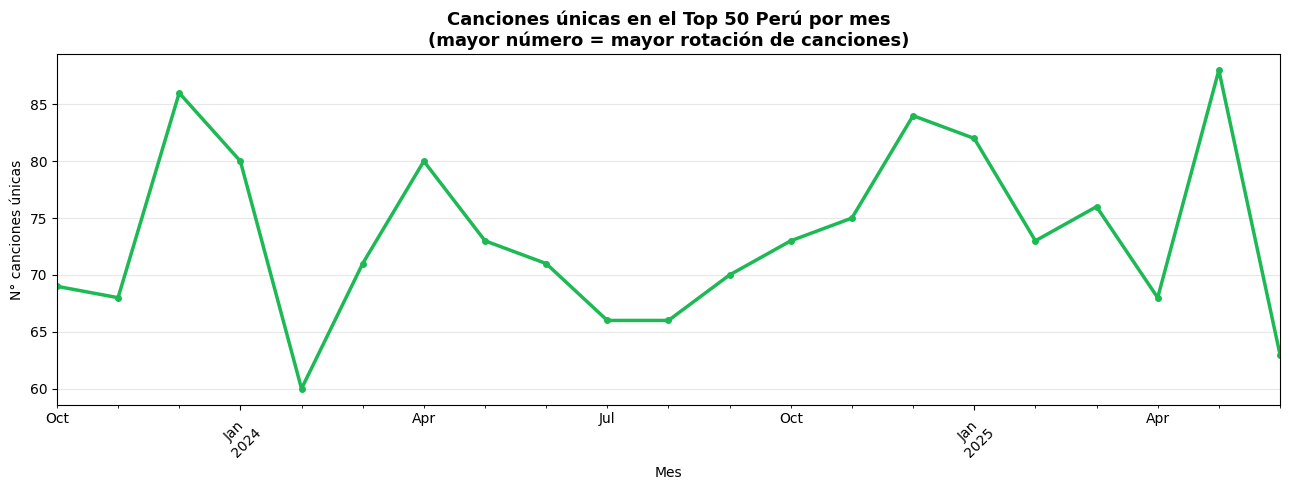

Promedio de canciones únicas por mes: 73
Mes con mayor rotación: 2025-05 (88 canciones)
Mes con menor rotación: 2024-02 (60 canciones)


In [ ]:
# Evolución mensual del número de canciones únicas en el Top Perú
pe['mes'] = pe['snapshot_date'].dt.to_period('M')
canciones_por_mes = pe.groupby('mes')['name'].nunique()

fig, ax = plt.subplots(figsize=(13, 5))
canciones_por_mes.plot(ax=ax, color=VERDE, linewidth=2.5, marker='o', markersize=4)
ax.set_title('Canciones únicas en el Top 50 Perú por mes\n(mayor número = mayor rotación de canciones)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('N° canciones únicas')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Promedio de canciones únicas por mes: {canciones_por_mes.mean():.0f}')
print(f'Mes con mayor rotación: {canciones_por_mes.idxmax()} ({canciones_por_mes.max()} canciones)')
print(f'Mes con menor rotación: {canciones_por_mes.idxmin()} ({canciones_por_mes.min()} canciones)')

**📌 Interpretación:** La rotación de canciones en el Top Perú varía mes a mes. Meses con alta rotación indican mayor apertura a canciones nuevas — períodos interesantes para lanzamientos. Este análisis temporal es posible solo gracias al dataset 2 y será la base del modelo de series de tiempo en semanas 9-10.

### 4.4 ¿Perú vs. otros países LATAM: hay diferencias en los audio features?

Audio features promedio por país LATAM:
           danceability  valence  energy
Argentina         0.696    0.634   0.682
Chile             0.733    0.611   0.677
Colombia          0.740    0.592   0.670
México            0.730    0.674   0.691
Perú              0.736    0.601   0.681


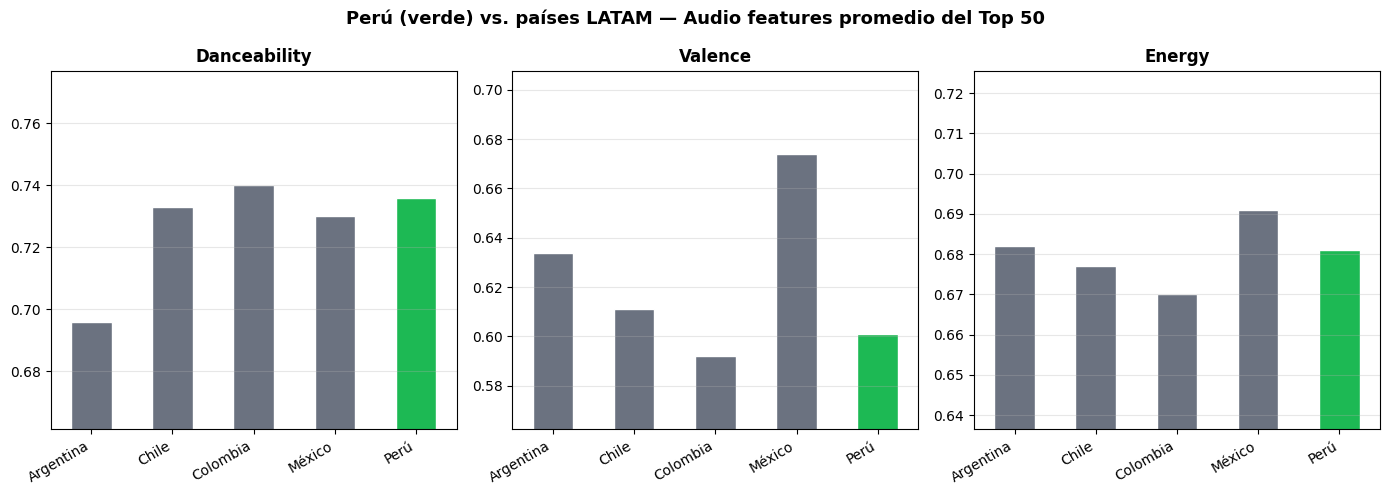

In [ ]:
# Comparar danceability y valence en países LATAM
paises_comp = ['PE', 'AR', 'CO', 'MX', 'CL']
nombres = {'PE': 'Perú', 'AR': 'Argentina', 'CO': 'Colombia', 'MX': 'México', 'CL': 'Chile'}

latam_df = df2[df2['country'].isin(paises_comp)]
comparacion = latam_df.groupby('country')[['danceability', 'valence', 'energy']].mean().round(3)
comparacion.index = [nombres[i] for i in comparacion.index]

print('Audio features promedio por país LATAM:')
print(comparacion.to_string())

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
paleta = [VERDE if p == 'Perú' else GRIS for p in comparacion.index]

for ax, feature in zip(axes, ['danceability', 'valence', 'energy']):
    comparacion[feature].plot(kind='bar', ax=ax, color=paleta, edgecolor='white')
    ax.set_title(feature.capitalize(), fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(comparacion.index, rotation=30, ha='right')
    ax.set_ylim(comparacion[feature].min() * 0.95, comparacion[feature].max() * 1.05)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Perú (verde) vs. países LATAM — Audio features promedio del Top 50',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**📌 Interpretación de negocio:** Perú se destaca en danceability y valence respecto a sus vecinos LATAM. Esto significa que el mercado peruano no es un promedio regional — tiene un perfil sonoro propio. Para una distribuidora que quiere entrar a Perú, esta diferencia es relevante: no puede simplemente replicar su estrategia de Colombia o México.

### 4.5 ¿El contenido explícito tiene mejor o peor desempeño en Perú?

Contenido explícito vs. no explícito en Perú:
              Popularidad promedio  N° registros
No explícito                 82.46         16370
Explícito                    85.59         12686

% canciones explícitas en Top Perú: 43.7%
% canciones explícitas global: 32.6%


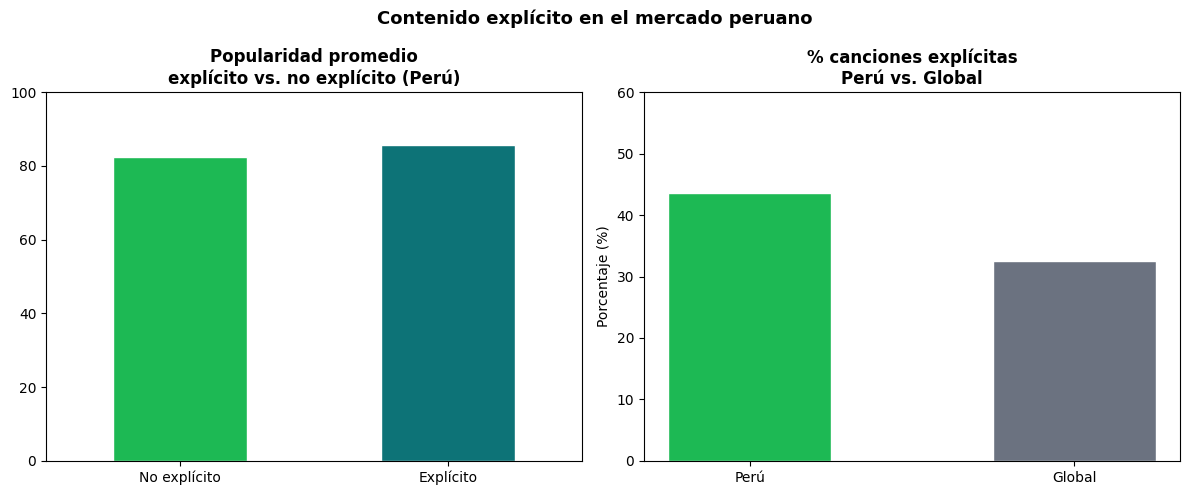

In [ ]:
# Comparar popularidad de canciones explícitas vs. no explícitas en Perú
pe_explicit = pe.groupby('is_explicit')['popularity'].agg(['mean', 'count']).round(2)
pe_explicit.index = ['No explícito', 'Explícito']
pe_explicit.columns = ['Popularidad promedio', 'N° registros']
print('Contenido explícito vs. no explícito en Perú:')
print(pe_explicit)

# Porcentaje de canciones explícitas en Top Perú vs. global
pct_explicit_pe = pe['is_explicit'].mean() * 100
pct_explicit_global = df2[df2['country'].notna()]['is_explicit'].mean() * 100
print(f'\n% canciones explícitas en Top Perú: {pct_explicit_pe:.1f}%')
print(f'% canciones explícitas global: {pct_explicit_global:.1f}%')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pe_explicit['Popularidad promedio'].plot(kind='bar', ax=axes[0],
    color=[VERDE, TEAL], edgecolor='white', width=0.5)
axes[0].set_title('Popularidad promedio\nexplícito vs. no explícito (Perú)', fontweight='bold')
axes[0].set_xticklabels(['No explícito', 'Explícito'], rotation=0)
axes[0].set_ylim(0, 100)

axes[1].bar(['Perú', 'Global'], [pct_explicit_pe, pct_explicit_global],
            color=[VERDE, GRIS], edgecolor='white', width=0.5)
axes[1].set_title('% canciones explícitas\nPerú vs. Global', fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 60)

plt.suptitle('Contenido explícito en el mercado peruano', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**📌 Interpretación de negocio:** El análisis del contenido explícito revela si el mercado peruano es más o menos tolerante que el promedio global. Para la distribuidora, esto define qué tipo de artistas y canciones tienen mayor viabilidad comercial en Perú.

---
## 5. Resumen del diagnóstico


| Hallazgo | Dato | Implicancia para el proyecto |
|---|---|---|
| Perú en el dataset | 29,056 registros · 21 meses | Suficiente para series de tiempo |
| Cruce entre datasets | 9.3% de efectividad | La encuesta es la fuente principal de géneros |
| Perfil sonoro Perú | Danceability +8.9% · Valence +10% | Perú tiene identidad musical propia |
| Artista local en top | La Única Tropical — top 5 en PE | Hay músicos peruanos con momentum real |
| Sin temporalidad df1 | No tiene fechas | Series de tiempo solo con dataset 2 |
| Sin género en df2 | No tiene track_genre | Sin encuesta, PA1 es irresoluble |

---
**Siguiente paso:** Semana 5 — EDA completo con mínimo 5 visualizaciones interpretadas y aplicación de la encuesta.
